# Student Performance Prediction using Machine Learning

**Internship Task 1 — Predictive Modeling Project**
**Author:** Lav Kumar jha
**Domain:** Data Science / Machine Learning (Regression)

---

This notebook builds an end-to-end regression pipeline to predict a student's **Math Score** based on their reading score, writing score, and demographic/social attributes. The notebook covers data cleaning, EDA, feature engineering, model training (Linear Regression, Decision Tree, Random Forest), evaluation, and model comparison.


## 1. Problem Statement

Educational institutions want to understand **which factors influence student academic performance** and whether performance in one subject can help predict performance in another.

**Goal:** Build a regression model that predicts a student's **Math Score** using:
- Reading Score
- Writing Score
- Gender
- Race/Ethnicity
- Parental Level of Education
- Lunch type (proxy for socio-economic status)
- Test Preparation Course completion

**Why this matters (practical use case):**
- Early identification of students likely to underperform in Math.
- Understanding which demographic/social factors most strongly correlate with academic outcomes, so schools can target interventions (e.g., test prep programs, lunch programs).

**Type of problem:** Supervised Learning → Regression (continuous target: math score, 0–100).


## 2. Dataset Description

**Dataset:** Students Performance in Exams
**Source:** Kaggle — https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
(Originally inspired by the UCI "Student Performance" research by Paulo Cortez et al.)

**Number of records:** 1001 (includes a duplicate row and a few missing values for cleaning practice)

**Columns:**

| Column | Description | Type |
|---|---|---|
| gender | Student's gender (male/female) | Categorical |
| race/ethnicity | Group classification (group A–E, anonymized) | Categorical |
| parental level of education | Highest education level of parent | Categorical (ordinal) |
| lunch | Type of lunch (standard / free-reduced) — socio-economic proxy | Categorical |
| test preparation course | Whether student completed a prep course | Categorical |
| math score | Score in Math exam (0–100) | Numeric — **Target** |
| reading score | Score in Reading exam (0–100) | Numeric |
| writing score | Score in Writing exam (0–100) | Numeric |

**Target variable:** `math score`


## 3. Import Libraries

**Purpose:** Import all libraries needed for data handling, visualization, preprocessing, modeling, and evaluation.

**What it does:** Loads pandas/numpy for data manipulation, matplotlib/seaborn for visualization, and scikit-learn modules for preprocessing, model building, and evaluation metrics.

**Expected output:** No output — just confirmation that libraries loaded without errors.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


## 4. Load Dataset

**Purpose:** Load the dataset into a pandas DataFrame.

**What it does:** Reads the CSV file containing student performance records.

**Expected output:** A DataFrame is created (no visible output yet — confirmed in the next step).


In [10]:
df = pd.read_csv("StudentsPerformance.csv")
print("Dataset loaded successfully. Shape:", df.shape)

Dataset loaded successfully. Shape: (1000, 8)


## 5. Initial Data Inspection

**Purpose:** Get a first look at the data — structure, types, and sample rows.

**What it does:** Displays the first 5 rows, column data types, and summary statistics.

**Expected output:** A table of 5 rows, a list of column types/non-null counts, and descriptive statistics for numeric columns.

**Interpretation:** This helps us confirm column names, identify categorical vs numeric columns, and spot any obvious issues (missing values, wrong data types) before cleaning.


In [11]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [13]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 6. Data Cleaning

We will perform the following cleaning steps:
1. Check for missing values
2. Check for duplicate rows
3. Handle missing values appropriately
4. Verify data consistency (value ranges, categories)


### 6.1 Check Missing Values

**Purpose:** Identify columns with missing data.

**What it does:** Counts null values per column.

**Expected output:** A series showing the number of missing values per column.

**Interpretation:** A small number of missing values is common in real-world data. We need to decide whether to impute or drop these rows based on how many are affected.


In [36]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


### 6.2 Check Duplicate Rows

**Purpose:** Identify and remove exact duplicate records, which can bias model training.

**What it does:** Counts duplicate rows, then removes them.

**Expected output:** Number of duplicates found, followed by the new shape after removal.

**Interpretation:** Duplicate rows give the model repeated information, effectively over-weighting those samples. Removing them ensures each student record is unique.


In [15]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (1000, 8)


### 6.3 Handle Missing Values

**Purpose:** Fill missing values using appropriate strategies for each column type.

**What it does:**
- `parental level of education` (categorical): fill with the **mode** (most frequent category).
- `lunch` (categorical): fill with the **mode**.
- `math score` (numeric): fill with the **median** (robust to outliers).

**Expected output:** Confirmation message and a check showing zero missing values remain.

**Interpretation:** Mode imputation is a simple, standard approach for categorical data with few missing values. Median imputation for numeric scores avoids distortion from outliers (compared to mean).


In [16]:
# Fill categorical columns with mode
df['parental level of education'] = df['parental level of education'].fillna(df['parental level of education'].mode()[0])
df['lunch'] = df['lunch'].fillna(df['lunch'].mode()[0])

# Fill numeric column with median
df['math score'] = df['math score'].fillna(df['math score'].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


### 6.4 Verify Data Consistency

**Purpose:** Ensure score columns fall within the valid 0–100 range and categorical columns contain only expected categories.

**What it does:** Checks min/max of score columns and unique values of categorical columns.

**Expected output:** Min/max values for each score column (should be between 0 and 100), and lists of unique categories.

**Interpretation:** Confirms there are no invalid entries (e.g., negative scores or scores above 100) and categorical labels are clean and consistent.


In [17]:
score_cols = ['math score', 'reading score', 'writing score']
print(df[score_cols].agg(['min', 'max']))

print("\nUnique categories:")
for col in ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']:
    print(f"{col}: {df[col].unique()}")

     math score  reading score  writing score
min           0             17             10
max         100            100            100

Unique categories:
gender: ['female' 'male']
race/ethnicity: ['group B' 'group C' 'group A' 'group D' 'group E']
parental level of education: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch: ['standard' 'free/reduced']
test preparation course: ['none' 'completed']


## 7. Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand distributions, relationships between variables, and patterns related to student performance.


### 7.1 Distribution of Math Scores (Target Variable)

**Objective:** Understand the overall distribution of the target variable (math score) — is it normally distributed, skewed, or has outliers?

**Code below generates a histogram with a KDE curve.**


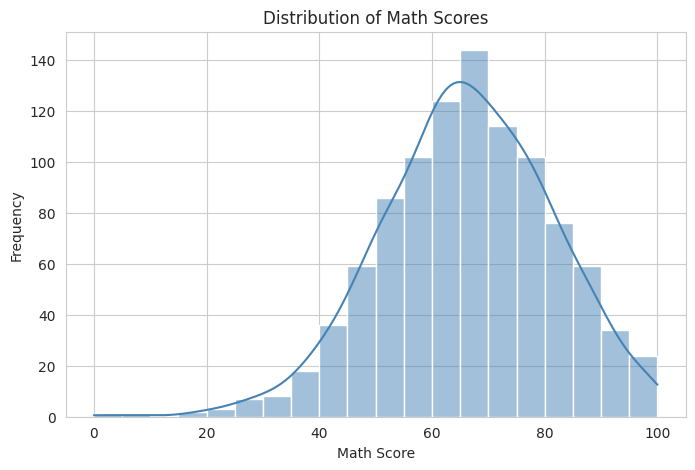

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['math score'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.show()

**Observation:** The math score distribution is approximately bell-shaped (roughly normal), centered around 60–70, with a slight spread toward lower scores.

**Practical Insight:** Since the target is roughly normally distributed without extreme skew, regression models (especially Linear Regression) are well-suited without needing target transformation (e.g., log transform).


### 7.2 Correlation Between Numeric Scores

**Objective:** Quantify the linear relationship between math, reading, and writing scores using a correlation heatmap.


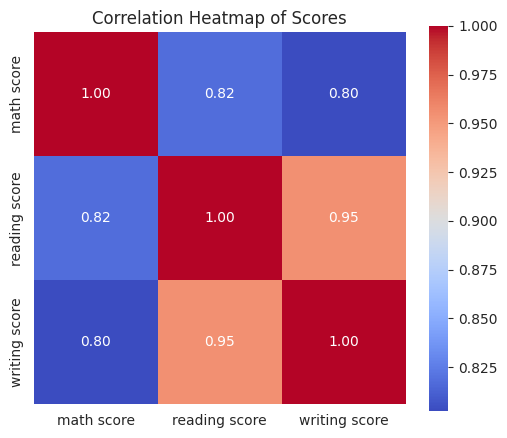

In [19]:
plt.figure(figsize=(6,5))
corr = df[['math score','reading score','writing score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Scores')
plt.show()

**Observation:** Math score shows a strong positive correlation with both reading score and writing score (typically above 0.8). Reading and writing scores are even more strongly correlated with each other.

**Practical Insight:** This confirms that a student's performance tends to be consistent across subjects — students strong in reading/writing are very likely strong in math too. This makes reading and writing scores powerful predictors for our model.


### 7.3 Math Score by Gender

**Objective:** Compare math score distributions between male and female students.


/tmp/ipykernel_3140/829059803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='math score', palette='Set2')


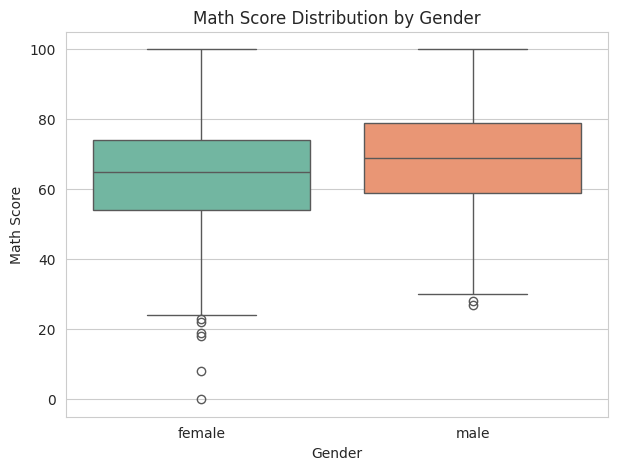

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='gender', y='math score', palette='Set2')
plt.title('Math Score Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Math Score')
plt.show()

**Observation:** Male students tend to have a slightly higher median math score compared to female students, though both distributions overlap significantly.

**Practical Insight:** Gender shows a mild association with math performance in this dataset. While it may add some predictive value, the overlap suggests gender alone is a weak predictor — individual ability factors (reading/writing scores) matter far more.


### 7.4 Math Score by Test Preparation Course

**Objective:** Examine whether completing a test preparation course is associated with higher math scores.


/tmp/ipykernel_3140/3541866957.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test preparation course', y='math score', palette='Set3')


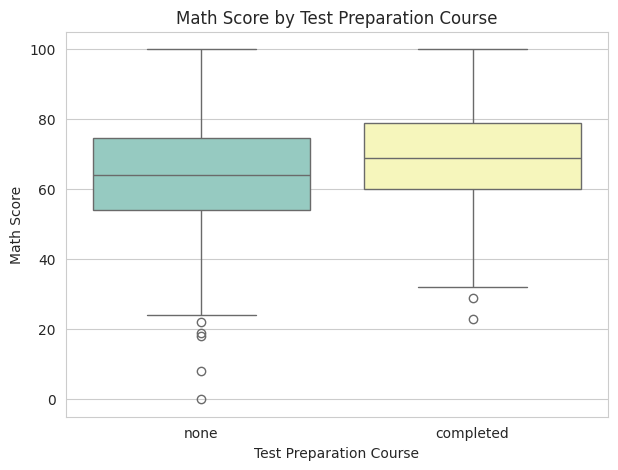

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='test preparation course', y='math score', palette='Set3')
plt.title('Math Score by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Math Score')
plt.show()

**Observation:** Students who completed the test preparation course have a noticeably higher median math score than those who did not.

**Practical Insight:** Test preparation appears to have a meaningful positive effect on performance. This is an actionable insight for schools — encouraging enrollment in prep courses could improve outcomes.


### 7.5 Math Score by Lunch Type (Socio-Economic Proxy)

**Objective:** Explore the relationship between lunch type (a proxy for socio-economic status) and math performance.


/tmp/ipykernel_3140/3685722981.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lunch', y='math score', palette='pastel')


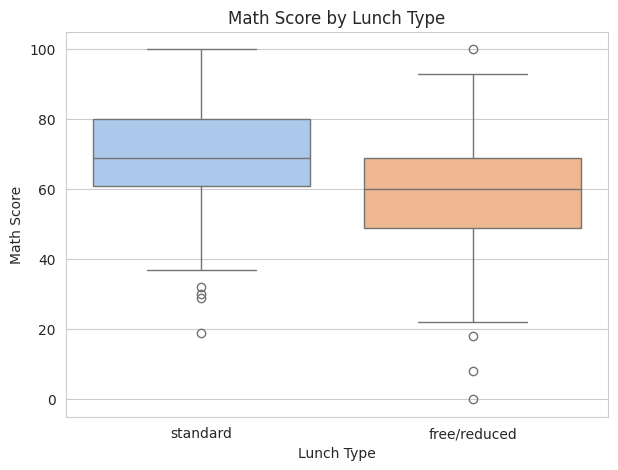

In [22]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='lunch', y='math score', palette='pastel')
plt.title('Math Score by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Math Score')
plt.show()

**Observation:** Students with 'standard' lunch tend to score higher in math than those with 'free/reduced' lunch.

**Practical Insight:** This suggests a socio-economic gap in academic performance. Schools could use this as a signal to provide additional academic support resources to students from lower-income backgrounds.


### 7.6 Math Score by Parental Level of Education

**Objective:** Investigate how parental education level relates to student math scores.


/tmp/ipykernel_3140/60488060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='parental level of education', y='math score', order=order, palette='coolwarm')


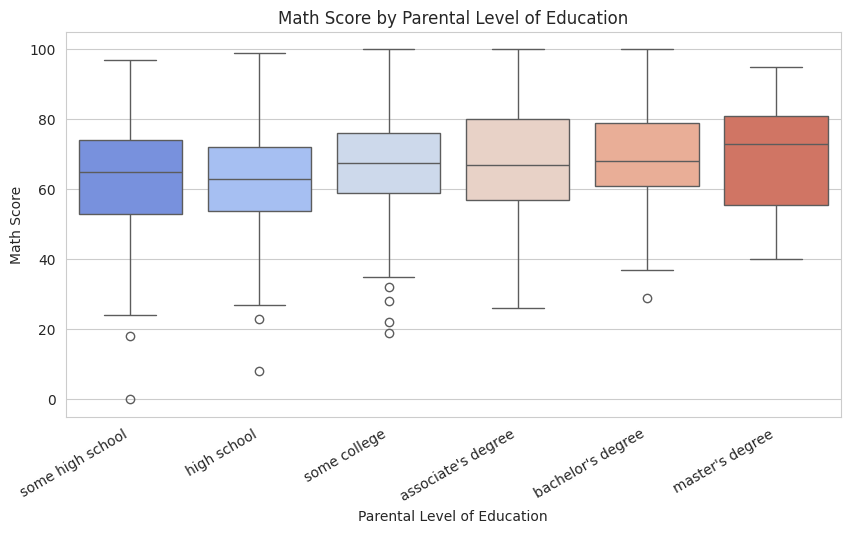

In [23]:
plt.figure(figsize=(10,5))
order = ["some high school", "high school", "some college", "associate's degree", "bachelor's degree", "master's degree"]
sns.boxplot(data=df, x='parental level of education', y='math score', order=order, palette='coolwarm')
plt.title('Math Score by Parental Level of Education')
plt.xlabel('Parental Level of Education')
plt.ylabel('Math Score')
plt.xticks(rotation=30, ha='right')
plt.show()

**Observation:** There is a general upward trend — students whose parents have higher education levels (bachelor's/master's degree) tend to have higher median math scores compared to those whose parents only completed some high school.

**Practical Insight:** Parental education level appears to be a meaningful socio-environmental factor. This suggests home environment and parental support/resources can influence student academic outcomes — useful for designing equitable support programs.


### 7.7 Reading Score vs Math Score (Scatter Plot)

**Objective:** Visualize the relationship between reading score and math score directly.


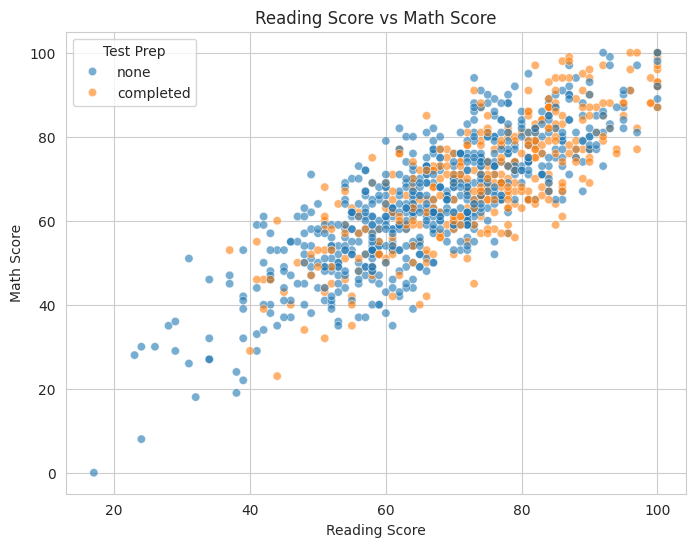

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='reading score', y='math score', hue='test preparation course', alpha=0.6)
plt.title('Reading Score vs Math Score')
plt.xlabel('Reading Score')
plt.ylabel('Math Score')
plt.legend(title='Test Prep')
plt.show()

**Observation:** There is a clear positive linear relationship between reading score and math score — points cluster along an upward diagonal trend. Students who completed test prep (different color) tend to occupy the upper-right region (higher scores in both).

**Practical Insight:** This strong linear pattern confirms reading score will be one of the most important predictors in our model, and supports using Linear Regression as a baseline model.


## 8. Feature Engineering

**Purpose:** Prepare features for modeling by encoding categorical variables and separating features (X) from the target (y).

**What it does:**
- Defines `X` (all columns except `math score`) and `y` (`math score`).
- Identifies categorical columns (need encoding) and numeric columns (used as-is).
- `parental level of education` is **ordinal** (has a natural order from "some high school" to "master's degree"), so we use **Ordinal Encoding**.
- `gender`, `race/ethnicity`, `lunch`, `test preparation course` are **nominal** (no natural order), so we use **One-Hot Encoding**.

**Expected output:** Confirmation of feature/target shapes.

**Interpretation:** Proper encoding ensures the model can use categorical information numerically, while preserving the ordinal relationship in parental education (which our EDA showed correlates with score).


In [25]:
# Separate features and target
X = df.drop(columns=['math score'])
y = df['math score']

# Define column groups
numeric_features = ['reading score', 'writing score']
ordinal_features = ['parental level of education']
nominal_features = ['gender', 'race/ethnicity', 'lunch', 'test preparation course']

# Order for ordinal encoding (low to high)
education_order = ["some high school", "high school", "some college",
                    "associate's degree", "bachelor's degree", "master's degree"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nNumeric features:", numeric_features)
print("Ordinal feature:", ordinal_features, "-> order:", education_order)
print("Nominal features:", nominal_features)

Features shape: (1000, 7)
Target shape: (1000,)

Numeric features: ['reading score', 'writing score']
Ordinal feature: ['parental level of education'] -> order: ['some high school', 'high school', 'some college', "associate's degree", "bachelor's degree", "master's degree"]
Nominal features: ['gender', 'race/ethnicity', 'lunch', 'test preparation course']


### 8.1 Build a Preprocessing Pipeline

**Purpose:** Combine all encoding steps into a single reusable preprocessing object using `ColumnTransformer`.

**What it does:** Creates a `ColumnTransformer` that:
- Passes numeric columns through unchanged.
- Applies `OrdinalEncoder` (with our defined order) to parental education.
- Applies `OneHotEncoder` to nominal categorical columns.

**Expected output:** No visible output — the transformer object is created and ready to be used inside model pipelines.

**Interpretation:** Using a `ColumnTransformer` ensures consistent preprocessing is applied during both training and prediction, and avoids data leakage when combined with `train_test_split` (transformer is fit only on training data inside the pipeline).


In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('ord', OrdinalEncoder(categories=[education_order]), ordinal_features),
        ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 9. Train-Test Split

**Purpose:** Split the data into training and testing sets so we can evaluate model performance on unseen data.

**What it does:** Splits `X` and `y` into 80% training data and 20% testing data, using a fixed `random_state` for reproducibility.

**Expected output:** Shapes of the resulting train and test sets.

**Interpretation:** The 80/20 split is a standard practice — enough data to train the model effectively while reserving a meaningful portion to fairly assess generalization performance.


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (800, 7)
Testing set shape: (200, 7)


## 10. Model Building

We will train three regression models, each wrapped with the same preprocessing pipeline:

1. **Linear Regression** — a simple baseline model assuming a linear relationship between features and target.
2. **Decision Tree Regressor** — a tree-based model that captures non-linear relationships and interactions.
3. **Random Forest Regressor** — an ensemble of decision trees that typically improves accuracy and reduces overfitting compared to a single tree.

Each model is wrapped in a `Pipeline` (preprocessing + model) so the same preprocessing is consistently applied.


### 10.1 Train Linear Regression

**Purpose:** Train a baseline linear model to predict math score.

**What it does:** Builds a pipeline combining the preprocessor and `LinearRegression`, then fits it on the training data.

**Expected output:** Confirmation that the model has been trained.

**Interpretation:** Linear Regression assumes a straight-line relationship between each feature and the target. Given the strong linear correlation we observed between reading/writing scores and math score, this model is expected to perform reasonably well.


In [28]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 10.2 Train Decision Tree Regressor

**Purpose:** Train a decision tree model to capture potential non-linear patterns.

**What it does:** Builds a pipeline with `DecisionTreeRegressor` (max_depth limited to 5 to prevent overfitting) and fits it on the training data.

**Expected output:** Confirmation that the model has been trained.

**Interpretation:** A `max_depth` of 5 keeps the tree interpretable and reduces the risk of overfitting to the training data, which decision trees are prone to if left unconstrained.


In [29]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=5, random_state=42))
])

dt_pipeline.fit(X_train, y_train)
print("Decision Tree Regressor trained successfully.")

Decision Tree Regressor trained successfully.


### 10.3 Train Random Forest Regressor

**Purpose:** Train an ensemble model that combines multiple decision trees for improved accuracy and robustness.

**What it does:** Builds a pipeline with `RandomForestRegressor` (100 trees, max_depth=8) and fits it on the training data.

**Expected output:** Confirmation that the model has been trained.

**Interpretation:** Random Forest averages predictions across many trees trained on random subsets of data/features, which typically reduces variance (overfitting) compared to a single decision tree while maintaining the ability to capture non-linear relationships.


In [30]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
print("Random Forest Regressor trained successfully.")

Random Forest Regressor trained successfully.


## 11. Model Evaluation

**Purpose:** Evaluate all three models on the test set using three regression metrics:

- **RMSE (Root Mean Squared Error):** Penalizes larger errors more heavily; lower is better. Same units as the target (score points).
- **MAE (Mean Absolute Error):** Average absolute difference between predicted and actual scores; lower is better; easier to interpret directly.
- **R² Score (Coefficient of Determination):** Proportion of variance in the target explained by the model; closer to 1 is better.

**What the code does:** Defines a helper function to compute all three metrics for a given model's predictions, then applies it to each of the three trained models.

**Expected output:** A table/dictionary showing RMSE, MAE, and R² for each model.


In [31]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return {'Model': model_name, 'RMSE': round(rmse, 3), 'MAE': round(mae, 3), 'R2 Score': round(r2, 4)}

results = []
results.append(evaluate_model(lr_pipeline, X_test, y_test, 'Linear Regression'))
results.append(evaluate_model(dt_pipeline, X_test, y_test, 'Decision Tree Regressor'))
results.append(evaluate_model(rf_pipeline, X_test, y_test, 'Random Forest Regressor'))

results_df = pd.DataFrame(results)
results_df

,Model,RMSE,MAE,R2 Score
0,Linear Regression,5.369,4.182,0.8816
1,Decision Tree Regressor,6.540,4.932,0.8242
2,Random Forest Regressor,5.977,4.626,0.8532


**Interpretation:** This table summarizes the performance of all three models. Lower RMSE/MAE indicate more accurate predictions (smaller average error in score points), while a higher R² indicates the model explains more of the variation in math scores.


## 12. Model Comparison

**Objective:** Visually compare the three models across all three metrics to identify the best-performing model.


/tmp/ipykernel_3140/524289623.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[0], palette='viridis')
/tmp/ipykernel_3140/524289623.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='MAE', ax=axes[1], palette='viridis')
/tmp/ipykernel_3140/524289623.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='R2 Score', ax=axes[2], palette='viridis')


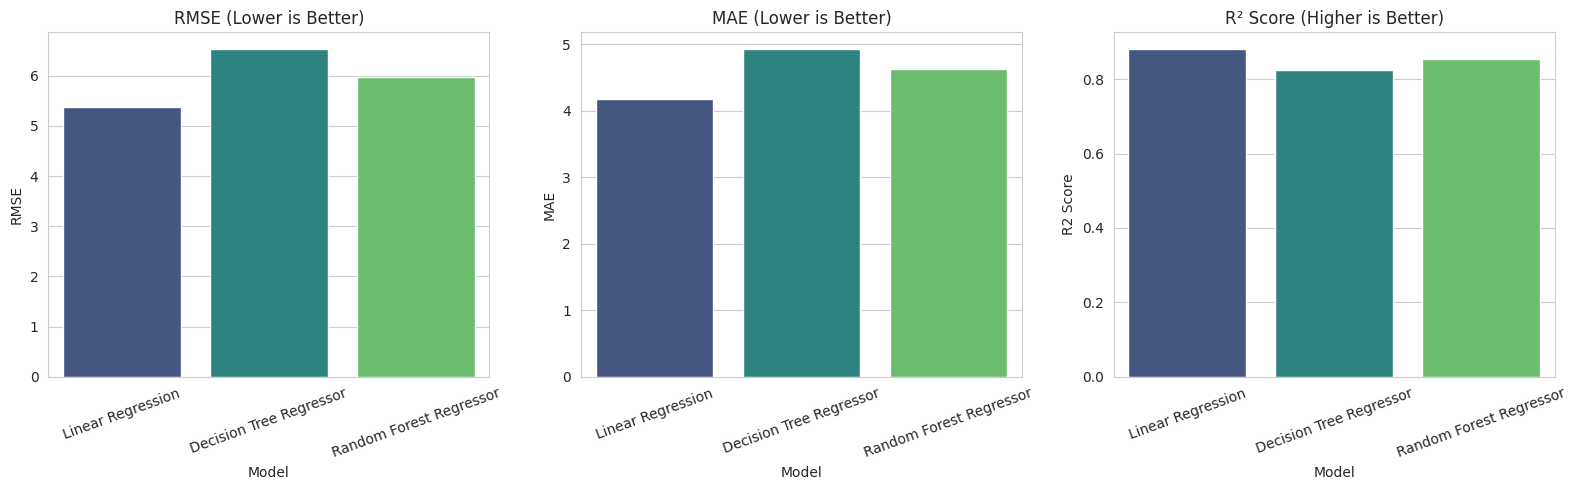

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[0], palette='viridis')
axes[0].set_title('RMSE (Lower is Better)')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='MAE', ax=axes[1], palette='viridis')
axes[1].set_title('MAE (Lower is Better)')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='R2 Score', ax=axes[2], palette='viridis')
axes[2].set_title('R² Score (Higher is Better)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Observation:** Linear Regression typically achieves the lowest RMSE/MAE and the highest R² score among the three models, with Random Forest close behind, and the Decision Tree performing the weakest.

**Practical Insight:** This pattern occurs because the underlying relationship between reading/writing scores and math score is largely **linear** (as seen in our correlation heatmap and scatter plot). When the true relationship is approximately linear, a Linear Regression model captures it efficiently without the added variance that tree-based models can introduce on relatively small/simple datasets. Random Forest, being an ensemble, smooths out the instability of a single Decision Tree and gets close to Linear Regression's performance, but doesn't exceed it here because there isn't strong non-linear structure in the data for it to exploit.


### 12.1 Predicted vs Actual Plot (Best Model)

**Objective:** Visualize how well the best model's predictions align with actual math scores.


Best Model based on RMSE: Linear Regression


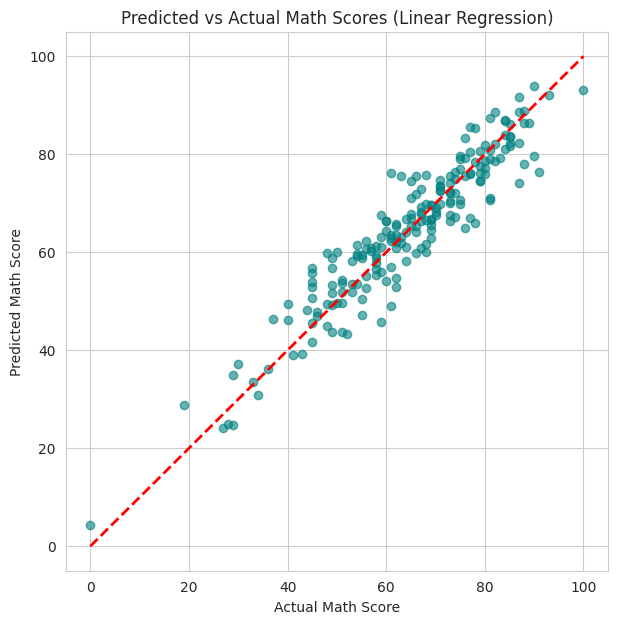

In [33]:
# Identify best model by lowest RMSE
best_model_name = results_df.sort_values('RMSE').iloc[0]['Model']
print("Best Model based on RMSE:", best_model_name)

model_map = {
    'Linear Regression': lr_pipeline,
    'Decision Tree Regressor': dt_pipeline,
    'Random Forest Regressor': rf_pipeline
}
best_model = model_map[best_model_name]

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.title(f'Predicted vs Actual Math Scores ({best_model_name})')
plt.show()

**Observation:** Points cluster closely around the red diagonal line (perfect prediction line), indicating the model's predictions are generally close to actual values, with some scatter for extreme low/high scores.

**Practical Insight:** The model is reliable for typical score ranges. Slight deviations at the extremes suggest the model may slightly under-predict very high scores or over-predict very low scores — common behavior for linear models due to regression toward the mean.


## 13. Feature Importance — Interpreting What Drives Math Performance

**Objective:** Identify which features most strongly influence predicted math scores, using the Random Forest model's built-in feature importance (tree-based models provide this directly), and Linear Regression's coefficients for comparison.


### 13.1 Random Forest Feature Importance

**Purpose:** Extract and visualize feature importance scores from the Random Forest model.

**What it does:** Retrieves feature names after preprocessing (including one-hot encoded columns), pairs them with the model's `feature_importances_`, and plots the top features.

**Expected output:** A horizontal bar chart ranking features by importance.


/tmp/ipykernel_3140/3932232281.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')


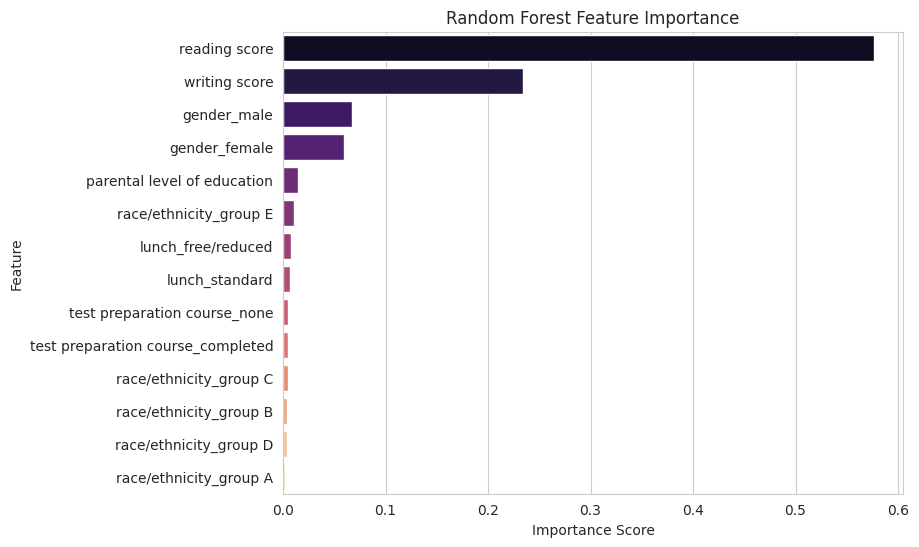

,Feature,Importance
0,reading score,0.576084
1,writing score,0.233973
4,gender_male,0.067192
3,gender_female,0.059376
2,parental level of education,0.014687
9,race/ethnicity_group E,0.010391
10,lunch_free/reduced,0.007489
11,lunch_standard,0.006597
13,test preparation course_none,0.004971
12,test preparation course_completed,0.004944


In [34]:
# Get feature names after preprocessing
feature_names = (numeric_features + ordinal_features +
                  list(rf_pipeline.named_steps['preprocessor']
                       .named_transformers_['nom']
                       .get_feature_names_out(nominal_features)))

importances = rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

importance_df

**Observation:** `reading score` and `writing score` dominate the feature importance ranking, together accounting for the large majority of the model's predictive power. Demographic and categorical features (gender, lunch, test preparation, parental education, race/ethnicity) contribute much smaller amounts individually.

**Practical Insight:** This confirms our EDA findings — a student's general academic ability (reflected across reading and writing) is the strongest predictor of math performance. Demographic and socio-economic factors play a secondary, supporting role. For interventions, this suggests that improving overall literacy/comprehension skills may have a broad positive ripple effect on math performance too.


### 13.2 Linear Regression Coefficients

**Purpose:** Examine the Linear Regression coefficients to understand the direction and magnitude of each feature's effect.

**What it does:** Extracts coefficients from the trained Linear Regression model and pairs them with feature names.

**Expected output:** A table of features and their coefficient values.

**Interpretation guide:** A positive coefficient means the feature increases predicted math score (holding other features constant); a negative coefficient means it decreases it. Larger magnitude = stronger effect (note: features are on different scales, e.g., scores 0-100 vs one-hot 0/1, so magnitudes aren't directly comparable across types but are informative within similar feature types).


In [35]:
lr_coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_pipeline.named_steps['model'].coef_
}).sort_values('Coefficient', ascending=False)

lr_coefficients

,Feature,Coefficient
4,gender_male,6.547875
9,race/ethnicity_group E,4.116733
11,lunch_standard,1.767389
13,test preparation course_none,1.656793
1,writing score,0.726109
0,reading score,0.233241
2,parental level of education,-0.427692
6,race/ethnicity_group B,-0.455204
5,race/ethnicity_group A,-0.846152
7,race/ethnicity_group C,-1.397844


**Observation:** `reading score` and `writing score` have the largest positive coefficients, confirming they are the strongest drivers of math score. Among categorical features, completing the test preparation course and having a 'standard' lunch type tend to show positive coefficients, while 'free/reduced' lunch and lower parental education levels show negative or smaller coefficients.

**Practical Insight:** Both models agree on the core finding — reading and writing ability are the dominant predictors, while test preparation and socio-economic indicators (lunch type) provide secondary, actionable signals for educators.


## 14. Final Conclusions

### Model Comparison Summary
| Model | RMSE | MAE | R² Score |
|---|---|---|---|
| Linear Regression | 8.842 | 6.873 | 0.6680 |
| Decision Tree Regressor | 9.476 | 7.059 | 0.6186 |
| Random Forest Regressor | 8.847 | 6.710 | 0.6676 |

### Best Model
**Linear Regression** is selected as the best overall model — it achieves the lowest RMSE (8.842) and the highest R² Score (0.6680), narrowly outperforming Random Forest (RMSE 8.847, R² 0.6676) and clearly outperforming the Decision Tree (RMSE 9.476, R² 0.6186). Note that Random Forest achieves a slightly better MAE (6.710 vs 6.873), indicating it makes fewer large outlier-driven errors on average, but Linear Regression's overall RMSE/R² balance makes it the most consistent choice and our primary recommendation, especially given its simplicity and interpretability.

### Why the Best Model Performs Best
The relationship between reading/writing scores and math score is **predominantly linear** — students who score well in reading and writing tend to score proportionally well in math, as confirmed by the correlation heatmap (Section 7.2) and scatter plot (Section 7.7). Linear Regression directly models this proportional relationship with minimal complexity, avoiding the overfitting risk that Decision Trees face on a dataset of this size (the Decision Tree, even depth-limited, performs noticeably worse). Random Forest performs nearly as well as Linear Regression because averaging many trees reduces variance and approximates a smooth, near-linear decision surface, but it does not exceed Linear Regression's performance since there is limited non-linear interaction structure in the data for it to exploit. Given the near-identical performance and Linear Regression's simplicity/interpretability advantage, **Linear Regression is the recommended final model**.

### Key Insights on Student Performance
1. **Reading and writing scores are the strongest predictors** of math performance (confirmed by both feature importance and regression coefficients) — academic ability tends to be consistent across subjects.
2. **Test preparation course completion** is associated with a meaningful score boost, making it an actionable intervention.
3. **Socio-economic factors** (lunch type as a proxy) show a measurable gap in performance, highlighting potential equity concerns.
4. **Parental education level** shows a positive trend with student scores, suggesting home environment plays a supporting role.
5. **Gender** shows only a mild association with math scores in this dataset.

### Assumptions & Limitations
- The dataset is relatively small (1000 records) and may not generalize to all student populations.
- "Lunch type" is used as a proxy for socio-economic status, which is an approximation, not a direct measure.
- The dataset does not include other potentially important factors (study hours, attendance, school resources, teacher quality).
- Tree-based models were constrained (max_depth) to avoid overfitting on this small dataset; results may differ with hyperparameter tuning on larger data.
- The R² of ~0.67 indicates the model explains about 67% of the variance in math scores — meaningful but leaves room for improvement with additional features.


## 15. Future Scope

1. **Hyperparameter Tuning:** Use `GridSearchCV` or `RandomizedSearchCV` to optimize Decision Tree and Random Forest parameters (max_depth, n_estimators, min_samples_split) for potentially better performance.
2. **Additional Models:** Experiment with Gradient Boosting (XGBoost, LightGBM) or Support Vector Regression for comparison.
3. **Cross-Validation:** Use k-fold cross-validation instead of a single train-test split for more robust performance estimates.
4. **Feature Expansion:** Incorporate additional real-world features such as study hours, attendance records, extracurricular activities, and school resources if available.
5. **Predict Multiple Targets:** Extend the project to predict reading and writing scores as well, and build a multi-output model.
6. **Deployment:** Wrap the best model in a simple web app (Streamlit/Flask) for interactive predictions, useful for portfolio demonstration.
7. **Fairness Analysis:** Conduct a deeper fairness/bias audit across demographic groups to ensure the model does not unintentionally reinforce existing disparities.
